In [1]:
import logging
import os
import time
import h5py
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import netket as nk
import optax
from scipy.sparse.linalg import eigsh
import pickle
import numpy as np
from NES_VMC_V1 import (
    NESTotalAnsatz,
    NESTotalAnsatz_stable,
    create_single_machine_gauge_fixed,
    Ham_Psi_scaled,
    NESFermionHopRule,
    ravel_pytree,
)
from NES_VMC_tool import create_gauge_reset_total_machines,NES_loss_energy_stable_gauge,\
    nes_vmc_gradient_stable_gauge,make_grad_fn_gauge,make_qgt_fn_gauge,make_gauge_fn
from H2_6_31G_6Qbit import SINGLE_SIZE, ha, hi_ext, ext_edges, K,hi,E_fcis,Hatree_Fock
import logging

/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: uv is a replacement for pip which helps you follow good software practices.

H2 分子基本信息 (6-31G)
HF energy = -0.99749729 Ha
Total electrons = (1, 1)
Total basis functions = 4
H2 / 6-31G FCI 基准能量（完整空间，8 比特）
E0 = -1.05434745 Ha  |  激发能: 0.0000 eV
E1 = -0.95790573 Ha  |  激发能: 2.6243 eV
E2 = -0.66895227 Ha  |  激发能: 10.4871 eV
E3 = -0.55140192 Ha  |  激发能: 13.6859 eV
E4 = -0.02803278 Ha  |  激发能: 27.9275 eV
E5 = -0.01450343 Ha  |  激发能: 28.2956 eV
E6 = -0.00518297 Ha  |  激发能: 28.5492 eV
E7 = 0.02397075 Ha  |  激发能: 29.3425 eV
E8 = 0.23432390 Ha  |  激发能: 35.0666 eV
E9 = 0.25720575 Ha  |  激发能: 35.6892 eV
E10 = 0.49958128 Ha  |  激发能: 42.2846 eV
E11 = 0.50024484 Ha  |  激发能: 42.3026 eV

活性空间 CASCI 参考（压缩正确性核对）
CAS(2,3) energy = -1.05173799 Ha
vs 完整 FCI E0        = -1.05434745 Ha
压缩损失              = 2.6095 mHa

压缩后 Hilbert 信息
空间轨道数 = 3  ->  自旋轨道(比特)数 hi.size = 6
粒子数扇区维数 = C(3,1) * C(3,1) = 9
HF reference state: [0 0 1 0 0 1]

Hamiltonian 类型: ParticleNumberAndSpinConservingFermioperator2nd
(原始: FermionOperator2ndJax)

K = 4
hi_ext.size = 24
single_edges (6): [(0, 1), (0, 2), (1, 

In [2]:

    
# ====================== 日志配置 ======================
time_str = time.strftime("%y-%m-%d-%H-%M")   # 输出文件名统一时间前缀 YY-DD-HH-MM
logger = logging.getLogger("NES_VMC_K4_gauge_reset")
logger.setLevel(logging.INFO)
logger.propagate = False
logger.handlers.clear()
simple_formatter = logging.Formatter("%(asctime)s %(message)s", datefmt="%y-%d-%H-%M")

os.makedirs("./日志", exist_ok=True)
log_path = f"./日志/{time_str}_nes_vmc_K4_H2_6-31G_gauge_reset.log"
file_handler = logging.FileHandler(log_path, mode="w", encoding="utf-8")
file_handler.setFormatter(simple_formatter)
logger.addHandler(file_handler)

console_handler = logging.StreamHandler()
console_handler.setFormatter(simple_formatter)
logger.addHandler(console_handler)

# ====================== 超参配置 ======================
N_CHAINS = 16
N_SAMPLES_PER_CHAIN = 200
SWEEP_SIZE = 20
N_ITER = 300
Natural_Grad = True
clip_norm = 20.0
per_param_clip = 1.0       # per-param 梯度范数上限：grad_norm/sqrt(n_params) 超过则缩放回 1（在 QGT 之前裁剪）
lr = 0.1
qgt_diag_shift = 0.1
RESET_PERIOD = 10          # 每隔多少步做一次 gauge reset（30 轮内 3 次）
SAVE_INTERVAL = 20         # 每多少步保存/追加一次 pickle
HISTORY_FILE = f"./data/{time_str}_history_natural_gradient_H2_molecule_K4.pkl"
os.makedirs("./data", exist_ok=True)

# ====================== 模型与采样器 ======================
total_ansatz = NESTotalAnsatz_stable(
    n_spin_orbitals=SINGLE_SIZE,
    n_states=K,
    hidden_dim=SINGLE_SIZE + K,
    rngs=nnx.Rngs(11),
)

g_current = jnp.zeros(K, dtype=jnp.complex64)   # 全局列规范 g，非训练参数，动态传入 jit

(
    total_machine,
    total_matrix_machine,
    total_max_machine,
    total_matrix_machine_raw,
    total_graphdef,
    total_params,
) = create_gauge_reset_total_machines(total_ansatz, Hatree_Fock)

single_machine_list = [
    create_single_machine_gauge_fixed(ansatz, Hatree_Fock)[0]
    for ansatz in total_ansatz.single_ansatz_list
]

grad_fn = make_grad_fn_gauge(
    ha,
    total_matrix_machine,
    total_max_machine,
    total_machine,
    single_machine_list,
)
qgt_fn = make_qgt_fn_gauge(total_machine)

gauge_fn, col_mean_fn = make_gauge_fn(total_ansatz, Hatree_Fock)

nes_rule = NESFermionHopRule(edges=ext_edges, K=K, single_size=SINGLE_SIZE)
nes_sampler = nk.sampler.MetropolisSampler(
    hilbert=hi_ext,
    rule=nes_rule,
    n_chains=N_CHAINS,
    sweep_size=SWEEP_SIZE,
)

# FCI 精确参考能量
exact_eigvals = E_fcis
# ====================== 优化器 ======================
optimizer = optax.chain(
    optax.clip_by_global_norm(clip_norm),
    optax.sgd(learning_rate=lr),
)
opt_state = optimizer.init(total_params)

sampler_rng = jax.random.PRNGKey(21)


def sample_machine(params, sigma):
    """双参数封装：采样只需要 |Ψ|² 的转移率，全局列规范 g 是常数平移，不影响 ratio。
    闭包每次调用读取 g_current 的最新值（g 作为动态参数传入 jit）。"""
    return total_machine(params, sigma, g_current)


sampler_state = nes_sampler.init_state(sample_machine, total_params, sampler_rng)

# ====================== 训练循环 ======================
logger.info("\n" + "=" * 60)
logger.info("开始多链 NES-VMC 训练 | P8: 双侧一致列规范 + 周期性 gauge reset")
logger.info(f"""超参数配置:\n\
N_CHAINS ={N_CHAINS}\n\
N_SAMPLES_PER_CHAIN ={N_SAMPLES_PER_CHAIN}\n\
SWEEP_SIZE = {SWEEP_SIZE}\n\
N_ITER = {N_ITER}\n\
Natural_Grad = {Natural_Grad}\n\
clip_norm = {clip_norm}\n\
per_param_clip = {per_param_clip}\n\
lr = {lr}\n\
qgt_diag_shift = {qgt_diag_shift}\n\
RESET_PERIOD = {RESET_PERIOD}\n\
SAVE_INTERVAL = {SAVE_INTERVAL}\
""")

logger.info("=" * 60)
logger.info(
    f"精确CAS基准：基态={exact_eigvals[0]:.8f} Ha | 1激发={exact_eigvals[1]:.8f} Ha"
    f"|2激发={exact_eigvals[2]:.8f} Ha|3激发={exact_eigvals[3]:.8f} Ha|"
)
logger.info(f"理论 Loss 上限：{sum(exact_eigvals[0:K]):.8f} ")
logger.info(f"超参：clip_norm={clip_norm}, per_param_clip={per_param_clip}, lr={lr}, QGT diag_shift={qgt_diag_shift}, RESET_PERIOD={RESET_PERIOD}")

import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt

loss_history = []
logpsi_history = []
steps_history = []
logpsi_mean_history = []
logpsi_min_history = []
logpsi_max_history = []
grad_norm_raw_history = []
grad_norm_per_param_history = []
grad_norm_nat_history = []
E_L_real_history = []
E_L_imag_history = []
params_history = []
Energy_levels_history = []
samples_history = []
gaugue_reset_history = []


start_time = time.time()

# ====================== 初始化/加载 pickle 历史文件 ======================
# 先尝试只读探测已有数据，支持断点续训
first_step = None
last_step = None
if os.path.exists(HISTORY_FILE):
    try:
        with open(HISTORY_FILE, "rb") as f:
            history = pickle.load(f)
        if history.get("steps"):
            last_step = int(history["steps"][-1])
            first_step = int(history["steps"][0])
            logger.info(f"检测到已有历史文件，上次保存 step={last_step}，将从 step={last_step + 1} 继续")
        else:
            logger.info("检测到历史文件但为空，将从头开始")
    except Exception as e:
        logger.warning(f"读取历史文件失败（可能损坏），将覆盖写入: {e}")
# ====================== 初始化结束 ======================


26-28-10-18 
26-28-10-18 开始多链 NES-VMC 训练 | P8: 双侧一致列规范 + 周期性 gauge reset
26-28-10-18 超参数配置:
N_CHAINS =16
N_SAMPLES_PER_CHAIN =200
SWEEP_SIZE = 20
N_ITER = 300
Natural_Grad = True
clip_norm = 20.0
lr = 0.1
qgt_diag_shift = 0.1
RESET_PERIOD = 10
SAVE_INTERVAL = 20
26-28-10-18 ============================================================
26-28-10-18 精确CAS基准：基态=-1.05434745 Ha | 1激发=-0.95790573 Ha|2激发=-0.66895227 Ha|3激发=-0.55140192 Ha|
26-28-10-18 理论 Loss 上限：-3.23260738 
26-28-10-18 超参：clip_norm=20.0, lr=0.1, QGT diag_shift=0.1, RESET_PERIOD=10


In [ ]:

for step in range(N_ITER):
    params_history.append(total_params)
    # 1. 采样
    samples_raw, sampler_state = nes_sampler.sample(
        machine=sample_machine,
        parameters=total_params,
        state=sampler_state,
        chain_length=N_SAMPLES_PER_CHAIN,
    )
    samples = samples_raw.reshape(-1, hi_ext.size)
    x_batch = samples.reshape(-1, K, SINGLE_SIZE)

    # 2. 梯度与损失
    grad_raw, loss_mean, E_L_mean, aux = grad_fn(total_params, x_batch, g_current)

    grad_raw_flat, unravel_fn = ravel_pytree(grad_raw)
    grad_norm_raw = jnp.linalg.norm(grad_raw_flat)
    n_params = grad_raw_flat.size   # 总参数个数
    grad_norm_per_param = grad_norm_raw / jnp.sqrt(n_params)

    # 【裁剪】per-param 梯度范数超过上限时按比例整体缩放（此步发生在计算 QGT 之前）
    if float(grad_norm_per_param) > per_param_clip:
        grad_scale = per_param_clip / float(grad_norm_per_param)
        grad_raw_flat = grad_raw_flat * grad_scale
        grad_raw = unravel_fn(grad_raw_flat)
        grad_norm_raw = jnp.linalg.norm(grad_raw_flat)
        grad_norm_per_param = grad_norm_raw / jnp.sqrt(n_params)
        logger.info(f"【Step {step}】per-param 梯度范数超限，已裁剪：scale={grad_scale:.4f} | 裁剪后 per_param={float(grad_norm_per_param):.4f}")

    grad_update = grad_raw

    has_nan = bool(jnp.any(jnp.isnan(grad_raw_flat)))
    if has_nan or grad_norm_raw > 5000.0:
        logger.warning(f"【Step {step} 告警】梯度异常！nan={has_nan}, raw_grad_norm={grad_norm_raw:.2f}")

    # 3. QGT 自然梯度
    if Natural_Grad:
        qgt_reg_mat = qgt_fn(total_params, x_batch, qgt_diag_shift, g_current)
        ng_flat = jnp.linalg.solve(qgt_reg_mat, grad_raw_flat)
        grad_update = unravel_fn(ng_flat)
        grad_norm_natural = jnp.linalg.norm(ng_flat)
    else:
        grad_norm_natural = grad_norm_raw

    # 4. 优化器内部完成梯度裁剪 + SGD 更新
    updates, opt_state = optimizer.update(grad_update, opt_state, total_params)
    total_params = optax.apply_updates(total_params, updates)

    grad_norm_clipped = min(float(grad_norm_natural), clip_norm)

    # 5. 能量监控：E_L 矩阵本征值
    eig_vals, _ = jnp.linalg.eig(E_L_mean)
    eig_vals = eig_vals[jnp.argsort(eig_vals.real)]

    # 6. 波函数与Ψ矩阵条件数监控（含 gauge 的值）
    log_Psi_batch = total_machine(total_params, x_batch, g_current)
    x_single = x_batch[0:1, ...]
    psi_mat = total_matrix_machine(total_params, x_single, g_current)[0]
    psi_cond = jnp.linalg.cond(psi_mat)

    gauge_now = float(jnp.real(gauge_fn(total_params, x_batch)))          # RAW L 的行规范坐标
    g_abs = float(jnp.linalg.norm(g_current))

    # 7. 日志（格式与 GaugeFixing00_K4_LiH_STO-3G.log 对齐）
    logger.info(f"[Step {step:3d}] logΨ: mean={log_Psi_batch.mean():.3f} | min={log_Psi_batch.min():.3f} | max={log_Psi_batch.max():.3f}")
    logger.info(f"梯度监控 | raw={grad_norm_raw:.4f} | per_param={grad_norm_per_param:.4f} |  natural={grad_norm_natural:.4f} | clipped={grad_norm_clipped:.4f}(上限{clip_norm})")
    logger.info(f"原始规范坐标 G(Re Σrow_mean) = {gauge_now:+.4f} | 累计|g| = {g_abs:.4f}")
    logger.info(f"Ψ矩阵条件数 cond(Ψ) = {psi_cond:.2e}")
    logger.info(
        f"Loss={loss_mean:.6f} | E0={eig_vals[0]:.8f} | E1={eig_vals[1]:.8f}"
        f"|E2={eig_vals[2]:.8f}|E3={eig_vals[3]:.8f}"
    )
    logger.info("#-----------------------------------------#")

    # 记录曲线数据（reset 发生在 step+1 边界，曲线上可直接观察回退）
    loss_history.append(float(jnp.real(loss_mean)))
    logpsi_history.append(float(jnp.real(log_Psi_batch.mean())))
    steps_history.append(step)

    # 记录监控数据（用于 pickle 保存）
    logpsi_mean_history.append(float(jnp.real(log_Psi_batch.mean())))
    logpsi_min_history.append(float(jnp.real(log_Psi_batch.min())))
    logpsi_max_history.append(float(jnp.real(log_Psi_batch.max())))
    grad_norm_raw_history.append(float(grad_norm_raw))
    grad_norm_nat_history.append(float(grad_norm_natural))
    grad_norm_per_param_history.append(float(grad_norm_per_param))
    E_L_real_history.append(float(jnp.real(jnp.trace(E_L_mean))))
    E_L_imag_history.append(float(jnp.imag(jnp.trace(E_L_mean))))
    Energy_levels_history.append(eig_vals[:K])
    samples_history.append(samples)
    
    

    # 每 SAVE_INTERVAL 步保存/追加一次 pickle
    if (step + 1) % SAVE_INTERVAL == 0:
        history = {
            "steps": [int(s) for s in steps_history],
            "logpsi_mean": logpsi_mean_history,
            "logpsi_min": logpsi_min_history,
            "logpsi_max": logpsi_max_history,
            "grad_norm_raw": grad_norm_raw_history,
            "grad_norm_natural": grad_norm_nat_history,
            "grad_norm_per_param": grad_norm_per_param_history,
            "E_L_real": E_L_real_history,
            "E_L_imag": E_L_imag_history,
            "loss": loss_history,
            "first_step": first_step if first_step is not None else 0,
            "save_interval": SAVE_INTERVAL,
            "Energy_levels": Energy_levels_history,
            "params": params_history,
        }
        
        
        with open(HISTORY_FILE, "wb") as f:
            pickle.dump(history, f)
        logger.info(f"[保存] Step {step} → pickle 文件已更新 ({len(steps_history)} 条记录)")

    # 8. 周期性 gauge reset：把 raw L 的列均值吸收进全局 g（双侧规范，物理不变）
    if (step + 1) % RESET_PERIOD == 0:
        new_col_mean = col_mean_fn(total_params, x_batch)   # (K,) 复数：当前列均值
        g_current = new_col_mean                # 模块级变量直接更新
        absorbed = float(jnp.sum(jnp.real(new_col_mean)))
        logger.info(
            f"[GaugeReset@{step + 1}] 吸收 Δg = Σ Re(col_mean) = {absorbed:+.4f} "
            f"| 新|g| = {float(jnp.linalg.norm(g_current)):.4f}"
        )

end_time = time.time()
logger.info(f"训练耗时：{end_time - start_time:.2f} 秒")
logger.info("\n" + "=" * 60)
logger.info("训练完成!")
logger.info("=" * 60)

# 训练结束后做最后一次写入确保数据完整
history = {
    "steps": [int(s) for s in steps_history],
    "logpsi_mean": logpsi_mean_history,
    "logpsi_min": logpsi_min_history,
    "logpsi_max": logpsi_max_history,
    "grad_norm_raw": grad_norm_raw_history,
    "grad_norm_natural": grad_norm_nat_history,
    "grad_norm_per_param": grad_norm_per_param_history,
    "E_L_real": E_L_real_history,
    "E_L_imag": E_L_imag_history,
    "loss": loss_history,
    "first_step": first_step if first_step is not None else 0,
    "save_interval": SAVE_INTERVAL,
    "Energy_levels": Energy_levels_history,
    "params": params_history,
    "samples": samples_history,
    
}
with open(HISTORY_FILE, "wb") as f:
    pickle.dump(history, f)
logger.info(f"[保存] 训练结束，pickle 最终写入 {len(steps_history)} 条记录 → {HISTORY_FILE}")



/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/jax/_src/ops/scatter.py:104: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=complex64 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(
26-28-10-19 [Step   0] logΨ: mean=0.622-0.137j | min=-1.566+0.230j | max=1.204+2.181j
26-28-10-19 梯度监控 | raw=1.9865 | per_param=0.0719 |  natural=0.7921 | clipped=0.7921(上限20.0)
26-28-10-19 原始规范坐标 G(Re Σrow_mean) = -0.3168 | 累计|g| = 0.0000
26-28-10-19 Ψ矩阵条件数 cond(Ψ) = 8.76e+00
26-28-10-19 Loss=-0.687549 | E0=-0.65644238+0.00928192j | E1=-0.40155272-0.00017989j|E2=-0.13863875-0.00805518j|E3=0.50908487+0.00011387j
26-28-10-19 #-----------------------------------------#
26-28-10-19 [Step   1] logΨ: mean=1.006-0.253j | min=-1.442-3.119j | max=1.634+2.136j
26-28-10-19 梯度监控 | raw=2.0263 | per_param=0.0733 |  natural=0.8107 | clipped=0.8107(上限20.0)
26-28-10-19 原始规范坐标 G(Re Σrow_mea

/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'grad_norm_per_param')

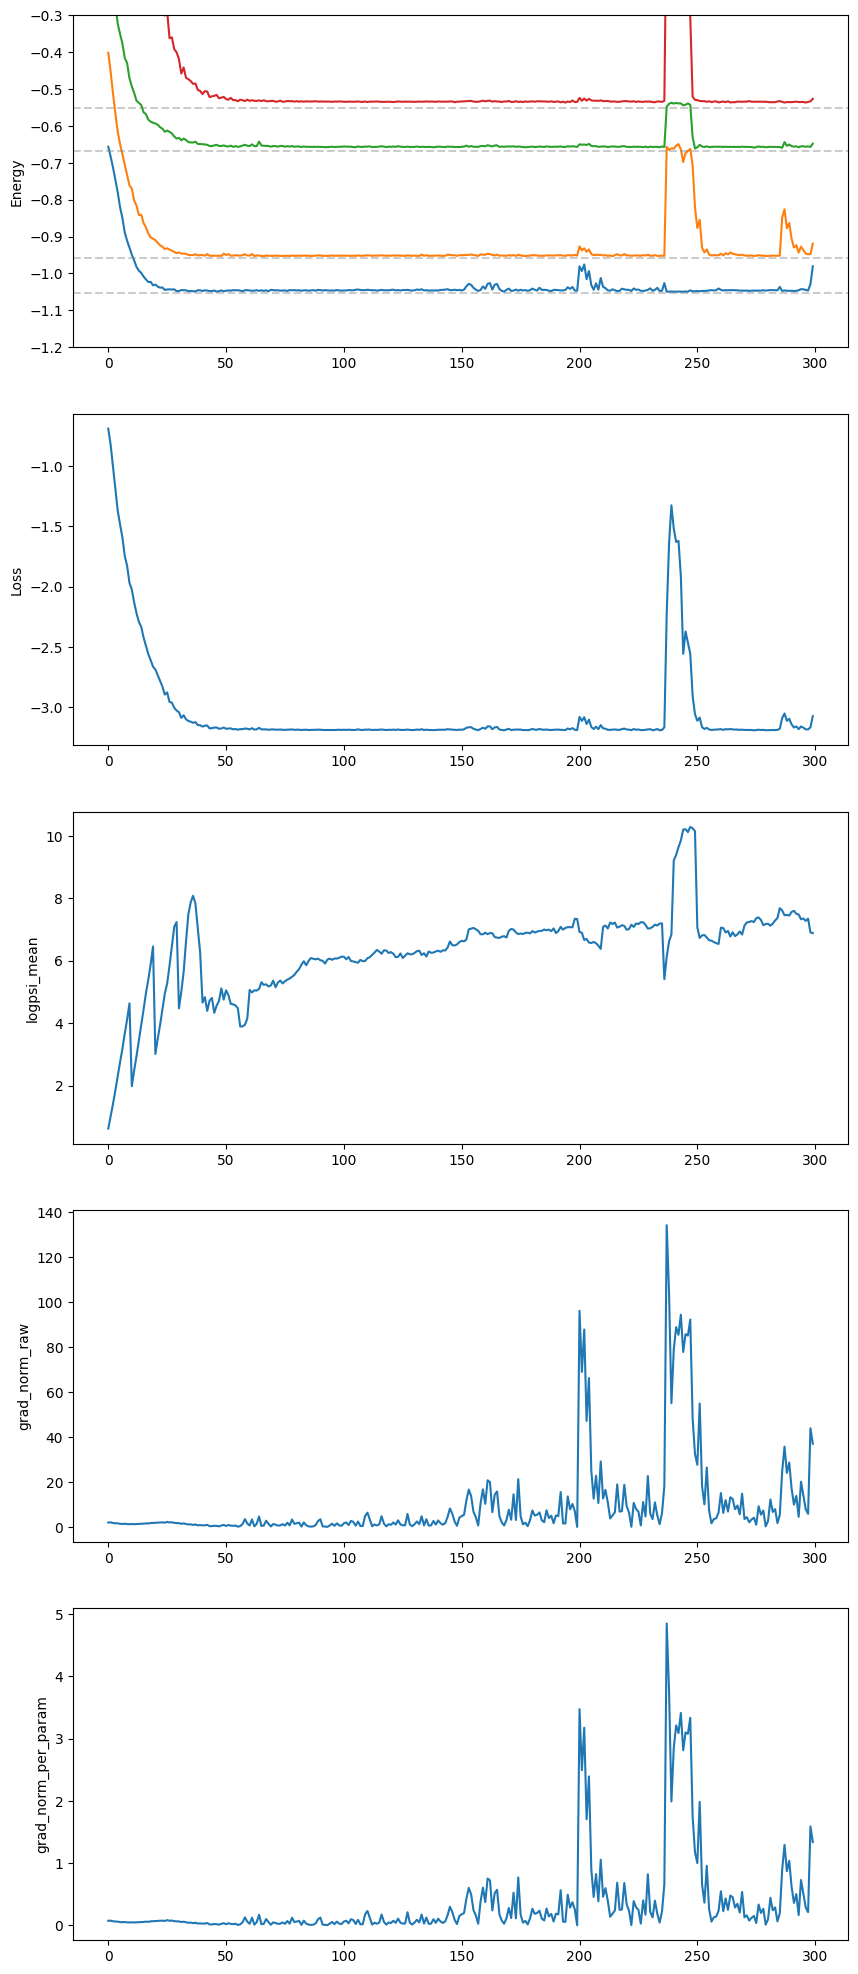

In [4]:
import matplotlib.pyplot as plt
fig,axs = plt.subplots(5, 1, figsize=(10, 25))
axs[0].plot(history['steps'],history["Energy_levels"])
for i in E_fcis:
    axs[0].axhline(i, color='gray', ls='--', alpha=0.4)

axs[0].set_ylabel("Energy")
axs[0].set_ylim(-1.2,-0.3)
axs[1].plot(history['steps'],history["loss"])
axs[1].set_ylabel("Loss")
axs[2].plot(history['steps'],history["logpsi_mean"])
axs[2].set_ylabel("logpsi_mean")
axs[3].plot(history['steps'],history["grad_norm_raw"])
axs[3].set_ylabel("grad_norm_raw")
axs[4].plot(history['steps'],history["grad_norm_per_param"])
axs[4].set_ylabel("grad_norm_per_param")


(-1.2, -0.3)

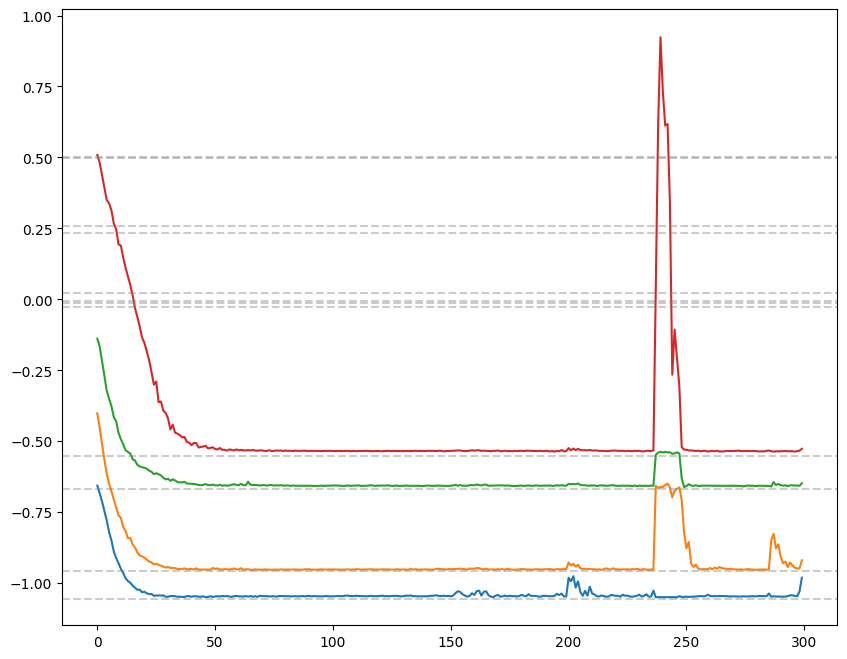

In [5]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(figsize=(10, 8))
ax.plot(history['steps'],history["Energy_levels"])
for i in E_fcis:
    ax.axhline(i, color='gray', ls='--', alpha=0.4)

axs[0].set_ylabel("Energy")
axs[0].set_ylim()